Importing Required Libraries:

In [2]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------- ----------------- 5.2/9.5 MB 23.7 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 24.7 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 20.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 25.3 MB/s  0:00:00
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)

   ---------------------------------------- 0/8 [pyparsing]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
 


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   -------------------------- ------------- 5.5/8.4 MB 29.2 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 25.1 MB/s  0:00:00
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl (37.4 MB)

   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ -------------------------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#Load the Titanic Dataset

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. LOAD DATA ONCE
# ============================================================

df = sns.load_dataset("titanic")

# Offline fallback
df.to_csv("titanic.csv", index=False)

print("Shape:")
print(df.shape)

print("\nInfo:")
print(df.info())

print("\nDescribe:")
print(df.describe(include="all"))

# ============================================================
# MISSING VALUE PERCENTAGES
# ============================================================

missing_pct = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_pct = missing_pct[missing_pct > 0]

print("\nMissing Value Percentages:")
print(missing_pct)


Shape:
(891, 15)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None

Describe:
          survived      pclass   sex         age      

Missing-value handling rule

In [3]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Interpretation
891 passengers are recorded in most columns.
Average survival rate = 0.38, meaning about 38% of passengers survived.
Average age = 29 years.
Average fare paid = 32.2.
Passenger ages range from 0.42 years to 80 years.
Fares range from 0 to 512.33.
Most passengers were in 3rd class (median pclass = 3).


Perform Data Cleaning

In [6]:
df_clean = df.copy()

for col in missing_pct.index:

    pct = missing_pct[col]

    print(f"{col}: {pct:.2f}%")

# <5% -> drop rows
# 5% - 30% -> impute
# >30% -> drop column or encode missing category

deck: 77.22%
age: 19.87%
embarked: 0.22%
embark_town: 0.22%


In [7]:
# embark_town
# around 0.22%
df_clean = df_clean.dropna(subset=["embark_town"])

# embarked
# around 0.22%
df_clean = df_clean.dropna(subset=["embarked"])

# age
# around 19.87%
df_clean["age"] = df_clean["age"].fillna(
    df_clean["age"].median()
)

# deck
# around 77%
# too sparse for meaningful imputation
df_clean = df_clean.drop(columns=["deck"])

# After cleaning
print(df_clean.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


Univariate analysis


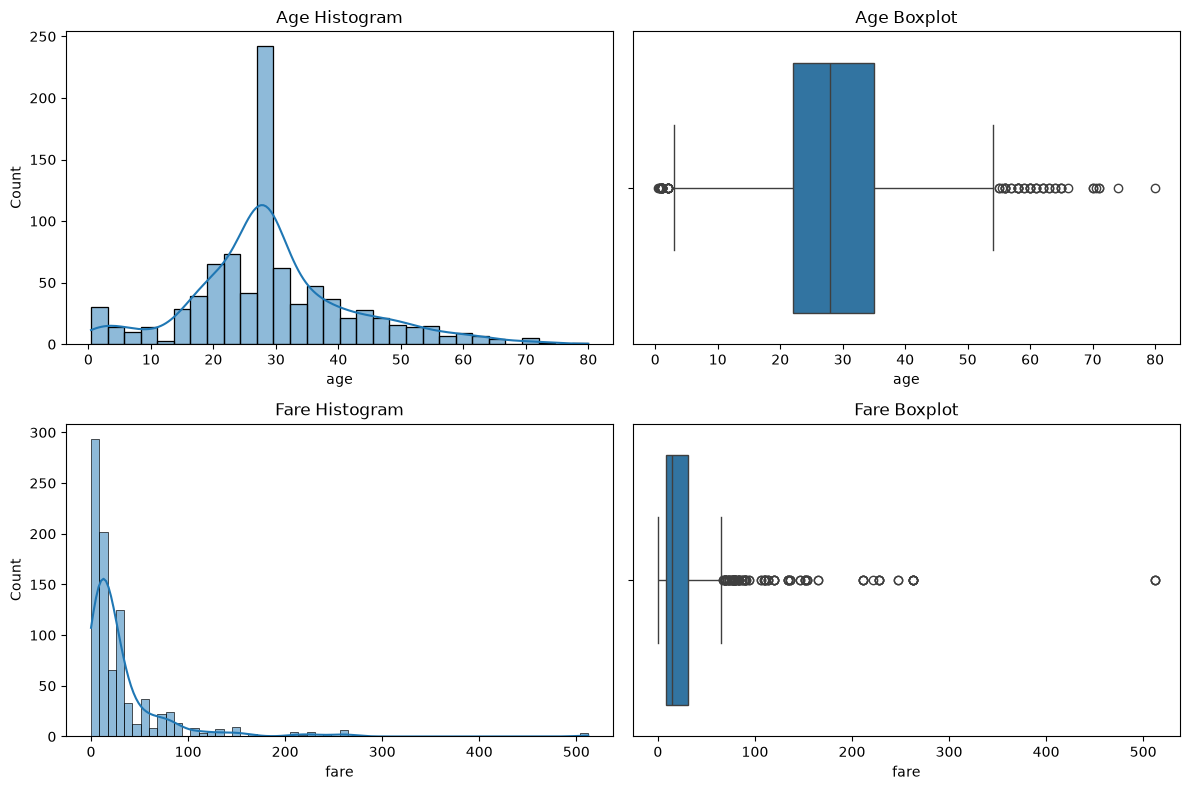

In [8]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

sns.histplot(df_clean["age"], kde=True, ax=ax[0,0])
ax[0,0].set_title("Age Histogram")

sns.boxplot(x=df_clean["age"], ax=ax[0,1])
ax[0,1].set_title("Age Boxplot")

sns.histplot(df_clean["fare"], kde=True, ax=ax[1,0])
ax[1,0].set_title("Fare Histogram")

sns.boxplot(x=df_clean["fare"], ax=ax[1,1])
ax[1,1].set_title("Fare Boxplot")

plt.tight_layout()
plt.show()

Conclusion
Age is fairly normally distributed with a few outliers.
Fare is heavily skewed and contains many extreme values (outliers).
This helps identify data patterns and potential preprocessing needs before modeling.

IQR outlier count

In [9]:
def count_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return ((series < lower) | (series > upper)).sum()

print("Age outliers:", count_outliers(df_clean["age"]))
print("Fare outliers:", count_outliers(df_clean["fare"]))

Age outliers: 65
Fare outliers: 114


65 age values are unusually low or high compared to most passengers.
114 fare values are much higher or lower than the normal fare range.

Mean, median, mode

In [10]:
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]

print("Mean:", fare_mean)
print("Median:", fare_median)
print("Mode:", fare_mode)

Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05


Conclusion
Age: 65 unusual values (outliers).
Fare: 114 unusual values, so fare has many extreme values.
Most passengers paid low fares, but a few paid very high fares.
Because of these high fares, the average fare (32.10) is much greater than the typical fare (median 14.45).

Bivariate Analysis

Survival by sex

In [11]:
for gender in df_clean["sex"].unique():

    rate = (
        df_clean[df_clean["sex"] == gender]["survived"]
        .mean()
        * 100
    )

    print(gender, rate)

male 18.890814558058924
female 74.03846153846155


Survival by class

In [12]:
for cls in sorted(df_clean["pclass"].unique()):

    rate = (
        df_clean[df_clean["pclass"] == cls]["survived"]
        .mean()
        * 100
    )

    print(cls, rate)

1 62.616822429906534
2 47.28260869565217
3 24.236252545824847


Overall Insight

The analysis shows that:

Women had a much higher survival rate than men.
Passengers in 1st class were more likely to survive than those in 2nd or 3rd class.
Gender and passenger class strongly influenced survival on the Titanic.

Survival by sex AND class (boolean masking)

In [13]:
for gender in ["male", "female"]:
    for cls in [1,2,3]:

        mask = (
            (df_clean["sex"] == gender) &
            (df_clean["pclass"] == cls)
        )

        rate = (
            df_clean.loc[mask, "survived"]
            .mean()
            * 100
        )

        print(gender, cls, rate)

male 1 36.885245901639344
male 2 15.74074074074074
male 3 13.544668587896252
female 1 96.73913043478261
female 2 92.10526315789474
female 3 50.0


Conclusion

Women and higher-class passengers had the best chance of survival, while men in lower classes had the lowest chance of survival on the Titanic.

Correlation matrix

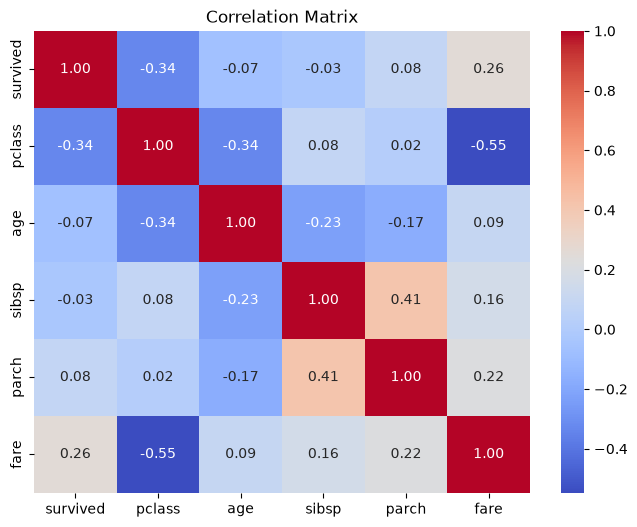

In [14]:
corr_cols = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr = df_clean[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

Overall Conclusion
Passenger class and fare had the biggest impact on survival.
Age had very little impact on survival.
People in 1st class who paid higher fares were more likely to survive.
Some family-related variables (sibsp and parch) are moderately related because families often traveled together.

Strongest correlations

In [15]:
corr_pairs = (
    corr.where(~np.eye(len(corr),dtype=bool))
        .stack()
        .abs()
        .sort_values(ascending=False)
)

print(corr_pairs.head(2))

pclass  fare      0.548193
fare    pclass    0.548193
dtype: float64


Multivariate Data Story

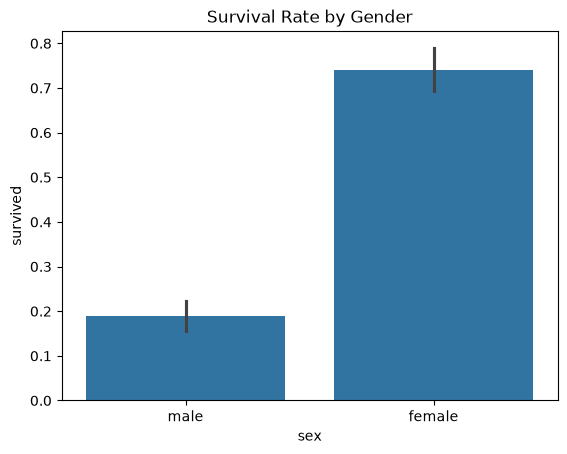

In [16]:
sns.barplot(
    data=df_clean,
    x="sex",
    y="survived"
)
plt.title("Survival Rate by Gender")
plt.show()

explanation: Female passengers had a much higher survival rate (about 74%) than male passengers (about 19%), showing that women were far more likely to survive on the Titanic.

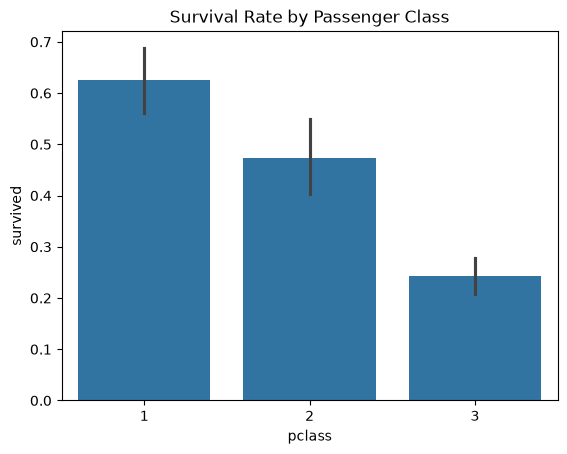

In [17]:
sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived"
)
plt.title("Survival Rate by Passenger Class")
plt.show()

Conclusion: The higher the passenger class, the better the chance of survival on the Titanic.

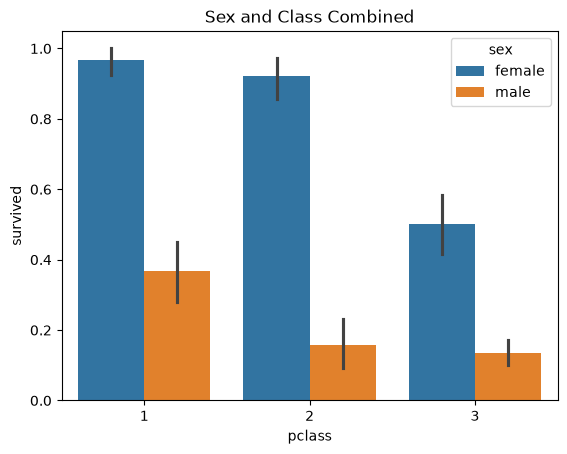

In [18]:
sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived",
    hue="sex"
)
plt.title("Sex and Class Combined")
plt.show()

Conclusion: Both gender and passenger class affected survival, with 1st-class women being the most likely to survive and 3rd-class men being the least likely to survive.

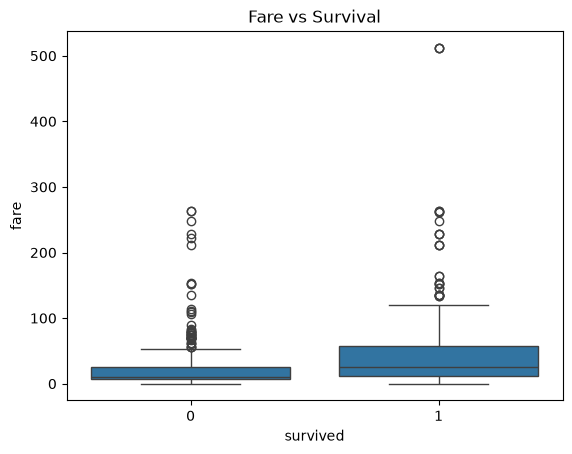

In [19]:
sns.boxplot(
    data=df_clean,
    x="survived",
    y="fare"
)
plt.title("Fare vs Survival")
plt.show()

Conclusion: People who paid higher fares, often linked to higher-class tickets, had a better chance of surviving the Titanic disaster.

Standardization Check

In [ ]:
z_df = df_clean.copy()

scaler = StandardScaler()

z_df[["age","fare"]] = scaler.fit_transform(
    z_df[["age","fare"]]
)

print("Original")
print(df_clean[["age","fare"]].agg(["mean","std"]))

print("\nStandardized")
print(z_df[["age","fare"]].agg(["mean","std"]))

Original
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

Standardized
               age          fare
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


: 